In [65]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import torch
import numpy as np
from model import WaveFunctionNN, train, predicted
from prepare_data import get_dataloader_from_csv_file, extract_t_and_y_from_loader
from draw_with_plot import plot_data_and_predicted, draw_t_distribution
import pandas as pd

In [67]:
SEED = 42
BATCH_SIZE = 100
HIDDEN_SIZE = 512
NUM_LAYERS = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 500

LR = 0.05

torch.manual_seed(42)
print(f"device: {DEVICE}")

device: cuda


In [68]:
train_loader, eval_loader, scaler = get_dataloader_from_csv_file('3pi_sin.csv', ['t'], ['y'], BATCH_SIZE)

model = WaveFunctionNN(HIDDEN_SIZE, NUM_LAYERS)

best_loss = train(model, train_loader, eval_loader, EPOCHS, LR, DEVICE, eval_method='grid')


Starting training on cuda for 500 epochs...
Gradient clipping enabled with max norm = 5.0
Epoch 1: New best composite score: 575.813278 → Model saved!
Epoch [1/500] | Train Loss: 1952712.976899 | Schrodinger: 0.000000 | Obs: -3.098484 | Norm: 1952716.052326 | Grad Norm: 8107845.1172 | Eval MAE: 6.047584 | Composite: 575.813278 | LR: 0.050000
Epoch 2: New best composite score: 104.236059 → Model saved!
Epoch [2/500] | Train Loss: 74391.751416 | Schrodinger: 0.000000 | Obs: -2.246507 | Norm: 74393.998750 | Grad Norm: 685720.9513 | Eval MAE: 16.452729 | Composite: 104.236059 | LR: 0.050000
Epoch 9: New best composite score: 97.785910 → Model saved!
Epoch [9/500] | Train Loss: 19697.690221 | Schrodinger: 0.000000 | Obs: -1.638264 | Norm: 19699.328198 | Grad Norm: 231529.7923 | Eval MAE: 12.888449 | Composite: 97.785910 | LR: 0.050000
Epoch 11: New best composite score: 91.498542 → Model saved!
Epoch [11/500] | Train Loss: 5301.903895 | Schrodinger: 0.000000 | Obs: -1.471938 | Norm: 5303.37

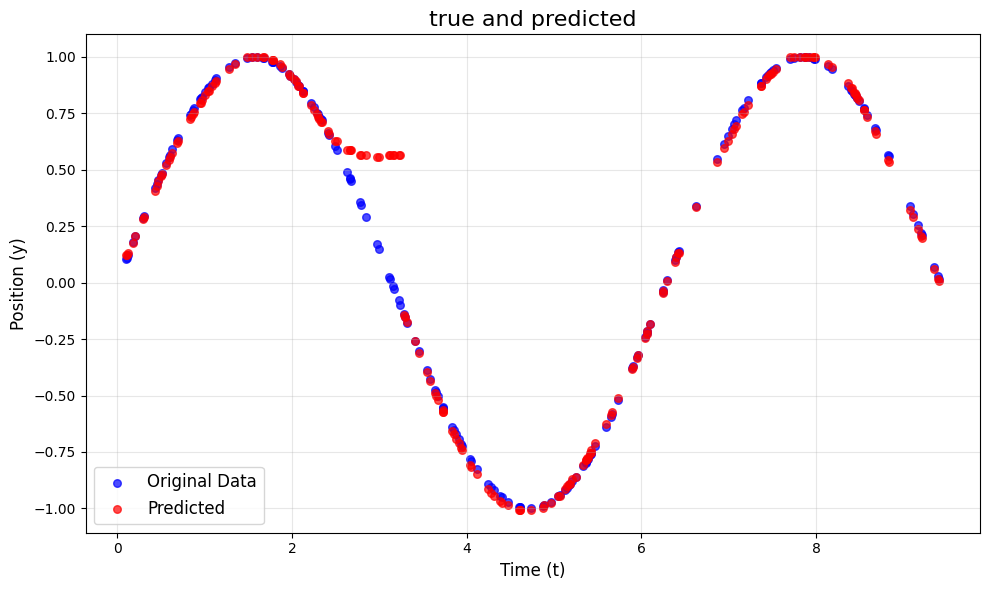

In [69]:
model.load_state_dict(torch.load('models_pth/best_model.pth'))

t, original_x = extract_t_and_y_from_loader(eval_loader)

predicted_t = torch.tensor(t.reshape(-1, 1)).to(DEVICE)
predicted_x = predicted(model, predicted_t, DEVICE)

predicted_t = predicted_t.cpu().numpy()
predicted_x = scaler.inverse_transform(predicted_x.cpu().numpy())

original_x = scaler.inverse_transform(original_x.reshape(-1, 1))

predicted_data = pd.DataFrame({'t': predicted_t.reshape(-1), 'y': predicted_x.reshape(-1)})
original_data = pd.DataFrame({'t': t.reshape(-1), 'y': original_x.reshape(-1)})

plot_data_and_predicted("true and predicted", original_data, predicted_data)

torch.Size([1000, 1]) torch.Size([1000, 1])


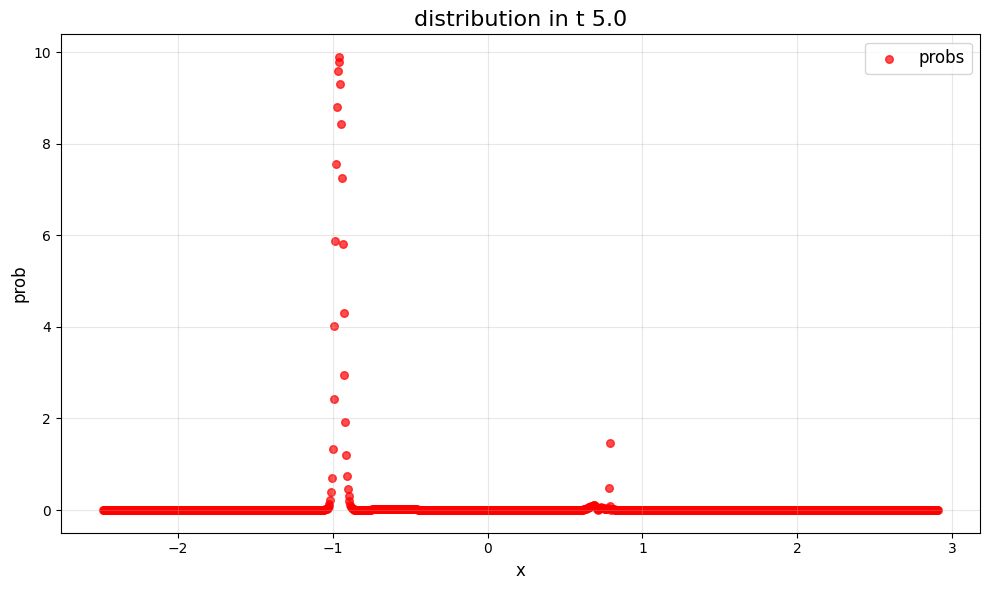

In [70]:
draw_t_distribution(model, 5., scaler, DEVICE)